In [1]:
# IMPORTING LIBRARIES

import re
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
# LOADING WHATSAPP CHAT

with open("chat.txt", "r", encoding="utf-8") as file:
    chat_text = file.read()

pattern = r'(\d{1,2}/\d{1,2}/\d{4}), (\d{1,2}:\d{2}\s?[ap]m) - ([^:]+): (.*?)(?=\n\d{1,2}/\d{1,2}/\d{4},|\Z)'

matches = re.findall(pattern, chat_text, re.DOTALL)

data = []

for date, time, name, message in matches:
    message = message.replace('\n', ' ').strip()
    
    if "Media omitted" in message or "end-to-end encrypted" in message:
        continue

    data.append([date, time, name, message])

df = pd.DataFrame(data, columns=["Date", "Time", "Name", "Chat"])


In [3]:
# CLEANING & FEATURE ENGINEERING

df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df = df.dropna(subset=['Date'])

df['Month'] = df['Date'].dt.strftime('%Y-%m')
df['Day'] = df['Date'].dt.day_name()

df['Time'] = df['Time'].str.lower()
df['Hour'] = pd.to_datetime(df['Time'], format='%I:%M %p', errors='coerce').dt.hour
df = df.dropna(subset=['Hour'])

In [4]:
# CREATE TRAINING DATA (FLIRT MODEL)

train_data = [
    ("That was really thoughtful of you", 1),
    ("I appreciate your support a lot", 1),
    ("You handled that very well", 1),
    ("Nice talking to you today", 1),
    ("You always bring positive energy", 1),
    
    ("Please share the report", 0),
    ("Let's schedule a meeting", 0),
    ("I will check and update", 0),
    ("Kindly confirm once done", 0),
    ("We will discuss this tomorrow", 0),
    ("Thanks for the update", 0),
    ("Noted", 0)
]

train_df = pd.DataFrame(train_data, columns=["Chat", "Label"])

In [5]:
# TRAIN THE ML MODEL

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(train_df['Chat'])
y_train = train_df['Label']

model = LogisticRegression()
model.fit(X_train, y_train)

print("\n✅ Flirt Classification Model Created")


✅ Flirt Classification Model Created


In [17]:
# APPLYING MODEL ON WHATSAPP DATA

X_test = vectorizer.transform(df['Chat'])
predictions = model.predict(X_test)

# Final single output
print("Flirt:", "Yes" if 1 in predictions else "No")

Flirt: Yes


In [7]:
# TALKATIVE vs LESS TALKATIVE

print("\n--- TALKATIVE ANALYSIS ---")

msg_count = df['Name'].value_counts()

print("Talkative Person:", msg_count.idxmax())
print("Less Talkative Person:", msg_count.idxmin())


--- TALKATIVE ANALYSIS ---
Talkative Person: Hakeem
Less Talkative Person: Rubhini_DCTeam


In [8]:
# MOST ACTIVE DAY & TIME

print("\n--- ACTIVITY ANALYSIS ---")

print("Most Active Day:", df['Day'].value_counts().idxmax())
print("Most Active Time:", int(df['Hour'].value_counts().idxmax()), ":00")


--- ACTIVITY ANALYSIS ---
Most Active Day: Monday
Most Active Time: 17 :00


In [9]:
# MOST ACTIVE DATE

most_active_date = df['Date'].dt.date.value_counts().idxmax()
print("Most Active Date:", most_active_date)

Most Active Date: 2026-03-23



--- MONTH TREND ---
Name     Hakeem  Rubhini_DCTeam
Month                          
2025-12      22              14
2026-01      29              31
2026-02      30              31
2026-03      90              93
2026-04      66              66


<Figure size 1000x500 with 0 Axes>

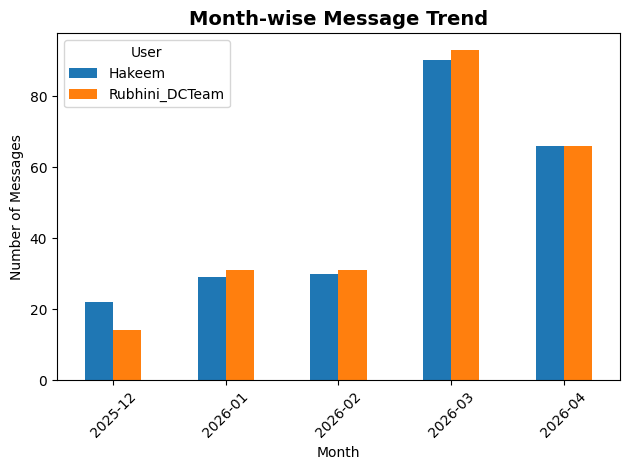

In [16]:
import matplotlib.pyplot as plt

print("\n--- MONTH TREND ---")

# Create pivot table
month_trend = df.groupby(['Month', 'Name']).size().unstack().fillna(0)

print(month_trend)

# Plot
plt.figure(figsize=(10,5))

month_trend.plot(kind='bar')

plt.title("Month-wise Message Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Messages")

plt.xticks(rotation=45)
plt.legend(title="User")
plt.tight_layout()

plt.show()

In [15]:
print("\n--- AVERAGE MESSAGES PER DAY ---")

# Count messages per day
daily_messages = df.groupby(df['Date'].dt.date).size()

# Calculate average
avg_messages = daily_messages.mean()

print("Average Messages per Day:", round(avg_messages, 2))


--- AVERAGE MESSAGES PER DAY ---
Average Messages per Day: 8.14


In [11]:
# MEDIA COUNT PER PERSON

print("\n--- MEDIA COUNT ---")

media_data = df[df['Chat'].str.contains("media", case=False)]
media_count = media_data.groupby('Name').size()

print(media_count if not media_count.empty else "No media shared")


--- MEDIA COUNT ---
Name
Hakeem            1
Rubhini_DCTeam    9
dtype: int64


In [12]:
# MISSED CALL ANALYSIS

print("\n--- MISSED CALLS ---")

missed_voice = df['Chat'].str.contains("missed voice call", case=False).sum()
missed_video = df['Chat'].str.contains("missed video call", case=False).sum()

print("Missed Voice Calls:", missed_voice if missed_voice > 0 else "No Missed Voice Calls")
print("Missed Video Calls:", missed_video if missed_video > 0 else "No Missed Video Calls")


--- MISSED CALLS ---
Missed Voice Calls: No Missed Voice Calls
Missed Video Calls: No Missed Video Calls


In [13]:
# DELETED MESSAGE COUNT

deleted_count = df['Chat'].str.contains("deleted", case=False).sum()

print("\nDeleted Messages:",
      "No message was deleted" if deleted_count == 0 else deleted_count)


Deleted Messages: 10


In [14]:
# SAVING THE OUTPUT

df.to_csv("whatsapp_output.csv", index=False)

print("\n✅ CSV created successfully")


✅ CSV created successfully
